# Load Packages

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from transformers import pipeline

In [2]:
# Custom functions
from custom_functions import (
    get_device,
    get_pipeline_device_id,
    analyze_sentiment,
    add_sentiment_score_columns,
    TRANSFORMER_SENTIMENT_OUTPUTS,
)

# Parameters

In [3]:
# Output directory — all plots and tables land here
output_dir = os.path.join("..", "outputs")
os.makedirs(output_dir, exist_ok=True)

# Data directory — all data files land here
data_raw_dir = os.path.join("..", "data", "raw")
data_processed_dir = os.path.join("..", "data", "processed")

# Load Clean Data

In [4]:
# Load dataset
toaster_clean_df = pd.read_csv(os.path.join(data_processed_dir, "toaster_clean.csv"))

# Data preview
toaster_clean_df.head()

,ASIN,P_TITLE,OP,DP,SP,FS,PRA_4.5,P_RTG,RTG_P_NO,SELLER_LINK,...,VP,HLP_VT,IMG_PRST,TTL_RV,RVS_L,RV_TRANS,SUBJ,SRVS,CP_RVS,BRAND
0,B01KZ729F6,Hamilton Beach 2 Slice Extra Wide Slot Toaster...,NaN,0.220000,NaN,1.0,0,4.4,12579.0,https://www.amazon.com/stores/HamiltonBeach/pa...,...,1,NaN,0,1669.0,31.0,Love making 4 slices at a time.,0.600000,positive,0.6369,Hamilton Beach
1,B0744M3SB4,Nostalgia TCS2 Grilled Cheese Toaster with Eas...,209.988477,0.786655,44.80,1.0,0,4.1,4156.0,https://www.amazon.com/stores/Nostalgia/page/B...,...,1,NaN,0,863.0,96.0,Great item to use if you love grilled cheese b...,0.675000,positive,0.8519,Nostalgia
2,B0BT5WXBR2,Elite Gourmet ECT118B Cool Touch Single Slice ...,14.990000,0.000000,14.99,1.0,0,NaN,NaN,https://www.amazon.com/stores/EliteGourmet/pag...,...,1,NaN,0,4078.0,79.0,I had high hopes for this toaster - but it ta...,0.320000,positive,0.4404,Elite Gourmet
3,B0B9MX21NV,"evoloop Toaster 2 Slice, Stainless Steel Bread...",279.850020,0.874969,34.99,1.0,0,4.4,31.0,https://www.amazon.com/stores/evoloop/page/087...,...,0,1.0,1,61.0,3565.0,BE AWARE: Read all the instructions included a...,0.509831,positive,0.9914,Evoloop
4,B0721CGB5F,BLACK+DECKER 4-Slice Toaster Oven with Natural...,64.990000,0.000000,64.99,1.0,0,4.4,25902.0,https://www.amazon.com/stores/BLACKDECKER/page...,...,1,NaN,0,3977.0,91.0,"This oven works very well, and does everything...",1.000000,positive,0.5719,BLACK+DECKER


In [5]:
toaster_clean_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 59586 entries, 0 to 59585
Data columns (total 31 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   ASIN         59586 non-null  str    
 1   P_TITLE      59586 non-null  str    
 2   OP           43859 non-null  float64
 3   DP           59586 non-null  float64
 4   SP           43859 non-null  float64
 5   FS           57322 non-null  float64
 6   PRA_4.5      59586 non-null  int64  
 7   P_RTG        56119 non-null  float64
 8   RTG_P_NO     56119 non-null  float64
 9   SELLER_LINK  59586 non-null  str    
 10  IMAGE_URL    59586 non-null  str    
 11  P_URL        59586 non-null  str    
 12  RV_URL       59586 non-null  str    
 13  PRFL_IMG     59586 non-null  str    
 14  PRFL_URL     59586 non-null  str    
 15  RV_TTL       59584 non-null  str    
 16  RVS          59586 non-null  str    
 17  RVR          59583 non-null  str    
 18  RSR          59586 non-null  int64  
 19  RVR_CONT     59

# Sentiment Analysis

In [6]:
# take a sample to speed up testing — remove or increase for full analysis
# toaster_clean_df = toaster_clean_df.sample(10, random_state=42).copy()

## Device Detection
This will help detect if there exist a GPU on the device.

In [7]:
device = get_device()
device_id = get_pipeline_device_id(device)

Using Apple MPS (Apple M2 Max)


## Load Sentiment Pipeline

In [8]:
# Label Mapping
LABEL_MAP = {
    # Standard text labels
    "positive": "positive",
    "negative": "negative",
    "neutral":  "neutral",
    # Numeric labels (verify order on the model's HuggingFace card!)
    "label_0":  "negative",
    "label_1":  "neutral",
    "label_2":  "positive",
}

In [9]:
# Different models to experiment with — each has its own strengths and weaknesses

# model_name = "nlptown/bert-base-multilingual-uncased-sentiment"
# model_name = "distilbert-base-uncased-finetuned-sst-2-english"
# model_name = "cardiffnlp/twitter-roberta-base-sentiment"
# model_name = "siebert/sentiment-roberta-large-english"
# model_name = "AnkitAI/reviews-roberta-base-sentiment-analysis"

### Twitter RoBERTa Base (CardiffNLP model)

In [10]:

model_twrb = "cardiffnlp/twitter-roberta-base-sentiment-latest"

sentiment_pipeline_twrb = pipeline(
    "sentiment-analysis",
    model=model_twrb,
    tokenizer=model_twrb,
    device=device_id,
    truncation=True,        # Handles long reviews (truncates to 512 tokens)
    max_length=512,
    batch_size=32,          # Process in batches for speed
)
# Analyze sentiment and add results to the DataFrame
toaster_clean_df = analyze_sentiment(
    toaster_clean_df,
    sentiment_pipeline=sentiment_pipeline_twrb,
    text_col="RV_TRANS",
    label_map=LABEL_MAP,
    sentiment_col="TWRB_SENT",
    score_col="TWRB_SCORE",
    neg_col="TWRB_neg",
    neu_col="TWRB_neu",
    pos_col="TWRB_pos",
    compound_col="TWRB_CS",
)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.weight | UNEXPECTED |  | 
roberta.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Analyzing 59585 texts (skipping 1 empty/invalid)...

Short texts (direct batch): 59495
Long texts (chunking + averaging): 90



Long texts: 100%|██████████| 90/90 [00:04<00:00, 19.64it/s]


Done. 90 text(s) used chunking + averaging.


In [11]:
# Check distribution of sentiment labels and review the long reviews that were chunked
print("\nSentiment Distribution:")
display(toaster_clean_df["TWRB_SENT"].value_counts())


Sentiment Distribution:


TWRB_SENT
positive    35978
negative    17087
neutral      6520
Name: count, dtype: int64

### RoBERTa Large English (Siebert model)

In [12]:
model_srb = "siebert/sentiment-roberta-large-english"

sentiment_pipeline_srb = pipeline(
    "sentiment-analysis",
    model=model_srb,
    tokenizer=model_srb,
    device=device_id,
    truncation=True,        # Handles long reviews (truncates to 512 tokens)
    max_length=512,
    batch_size=32,          # Process in batches for speed
)
# Analyze sentiment and add results to the DataFrame
toaster_clean_df = analyze_sentiment(
    toaster_clean_df,
    sentiment_pipeline=sentiment_pipeline_srb,
    text_col="RV_TRANS",
    label_map=LABEL_MAP,
    sentiment_col="SRB_SENT",
    score_col="SRB_SCORE",
    neg_col="SRB_neg",
    neu_col="SRB_neu",
    pos_col="SRB_pos",
    compound_col="SRB_CS",
)

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (845 > 512). Running this sequence through the model will result in indexing errors


Analyzing 59585 texts (skipping 1 empty/invalid)...

Short texts (direct batch): 59495
Long texts (chunking + averaging): 90



Long texts: 100%|██████████| 90/90 [00:11<00:00,  7.75it/s]


Done. 90 text(s) used chunking + averaging.


In [13]:
# Check distribution of sentiment labels and review the long reviews that were chunked
print("\nSentiment Distribution:")
display(toaster_clean_df["SRB_SENT"].value_counts())


Sentiment Distribution:


SRB_SENT
positive    38849
negative    20736
Name: count, dtype: int64

### Reviews RoBERTa Base

In [14]:
model_rvrb = "AnkitAI/reviews-roberta-base-sentiment-analysis"

sentiment_pipeline_rvrb = pipeline(
    "sentiment-analysis",
    model=model_rvrb,
    tokenizer=model_rvrb,
    device=device_id,
    truncation=True,        # Handles long reviews (truncates to 512 tokens)
    max_length=512,
    batch_size=32,          # Process in batches for speed
)
# Analyze sentiment and add results to the DataFrame
toaster_clean_df = analyze_sentiment(
    toaster_clean_df,
    sentiment_pipeline=sentiment_pipeline_rvrb,
    text_col="RV_TRANS",
    label_map=LABEL_MAP,
    sentiment_col="RVRB_SENT",
    score_col="RVRB_SCORE",
    neg_col="RVRB_neg",
    neu_col="RVRB_neu",
    pos_col="RVRB_pos",
    compound_col="RVRB_CS",
)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Analyzing 59585 texts (skipping 1 empty/invalid)...

Short texts (direct batch): 59495
Long texts (chunking + averaging): 90



Long texts: 100%|██████████| 90/90 [00:04<00:00, 21.63it/s]


Done. 90 text(s) used chunking + averaging.


In [15]:
# Check distribution of sentiment labels and review the long reviews that were chunked
print("\nSentiment Distribution:")
display(toaster_clean_df["RVRB_SENT"].value_counts())


Sentiment Distribution:


RVRB_SENT
positive    38411
negative    21174
Name: count, dtype: int64

## Results

In [16]:
# Review the results
cols = [
    "RV_TRANS",
    "SRVS",
    "CP_RVS",
    "TWRB_SENT",
    "TWRB_SCORE",
    "TWRB_neg",
    "TWRB_neu",
    "TWRB_pos",
    "TWRB_CS",
    "SRB_SENT",
    "SRB_SCORE",
    "SRB_neg",
    "SRB_neu",
    "SRB_pos",
    "SRB_CS",
    "RVRB_SENT",
    "RVRB_SCORE",
    "RVRB_neg",
    "RVRB_neu",
    "RVRB_pos",
    "RVRB_CS",
]
pd.set_option("display.max_colwidth", 120)
display(toaster_clean_df[cols].head())

,RV_TRANS,SRVS,CP_RVS,TWRB_SENT,TWRB_SCORE,TWRB_neg,TWRB_neu,TWRB_pos,TWRB_CS,SRB_SENT,...,SRB_neg,SRB_neu,SRB_pos,SRB_CS,RVRB_SENT,RVRB_SCORE,RVRB_neg,RVRB_neu,RVRB_pos,RVRB_CS
0,Love making 4 slices at a time.,positive,0.6369,positive,0.967,0.004,0.029,0.967,0.963,positive,...,0.0012,0.0,0.9988,0.9976,positive,0.9982,0.0018,0.0,0.9982,0.9964
1,Great item to use if you love grilled cheese but you have to use thin sliced bread only downfall,positive,0.8519,positive,0.8974,0.0168,0.0858,0.8974,0.8806,positive,...,0.0018,0.0,0.9982,0.9964,positive,0.9938,0.0062,0.0,0.9938,0.9876
2,I had high hopes for this toaster - but it takes two cycles to brown properly.,positive,0.4404,negative,0.7371,0.7371,0.2011,0.0618,-0.6753,negative,...,0.9995,0.0,0.0005,-0.999,negative,0.9986,0.9986,0.0,0.0014,-0.9972
3,BE AWARE: Read all the instructions included as this warning exists there: the first time (and maybe the 2nd & 3rd t...,positive,0.9914,neutral,0.6821,0.2334,0.6821,0.0845,-0.1489,positive,...,0.0022,0.0,0.9979,0.9957,negative,0.5023,0.5023,0.0,0.4977,-0.0046
4,"This oven works very well, and does everything it's supposed to do. I'm very happy with it!",positive,0.5719,positive,0.9867,0.0029,0.0103,0.9867,0.9838,positive,...,0.0011,0.0,0.9989,0.9978,positive,0.9986,0.0014,0.0,0.9986,0.9972


## Save Results to File

In [17]:
toaster_clean_df.to_csv(os.path.join(data_processed_dir, "toaster_sentiment.csv"), index=False)

In [18]:
# Read the saved file to skip the sentiment analysis step if we just want to review results
toaster_clean_df = pd.read_csv(os.path.join(data_processed_dir, "toaster_sentiment.csv"))

# Recreate probability and compound-score columns when loading an older saved sentiment file.
for sentiment_col, score_col, neg_col, neu_col, pos_col, compound_col in TRANSFORMER_SENTIMENT_OUTPUTS:
    output_cols = [neg_col, neu_col, pos_col, compound_col]
    if any(col not in toaster_clean_df.columns for col in output_cols):
        toaster_clean_df = add_sentiment_score_columns(
            toaster_clean_df,
            sentiment_col=sentiment_col,
            score_col=score_col,
            neg_col=neg_col,
            neu_col=neu_col,
            pos_col=pos_col,
            compound_col=compound_col,
        )

# Compare Results

In [19]:
# Extract relevant columns for comparison
compare_df = toaster_clean_df[["RV_TRANS", "SRVS", "TWRB_SENT", "SRB_SENT", "RVRB_SENT"]].copy()

# Normalize text labels
compare_df["SRVS_clean"] = (
    compare_df["SRVS"]
    .astype("string")
    .str.strip()
    .str.lower()
)

compare_df["TWRB_SENT_clean"] = (
    compare_df["TWRB_SENT"]
    .astype("string")
    .str.strip()
    .str.lower()
)

compare_df["SRB_SENT_clean"] = (
    compare_df["SRB_SENT"]
    .astype("string")
    .str.strip()
    .str.lower()
)

compare_df["RVRB_SENT_clean"] = (
    compare_df["RVRB_SENT"]
    .astype("string") 
    .str.strip()
    .str.lower()
)

In [20]:
# Keep only rows where both columns are available
compare_valid = compare_df.dropna(subset=["SRVS_clean", "TWRB_SENT_clean", "SRB_SENT_clean", "RVRB_SENT_clean"]).copy()

# Check match between SRVS and TWRB_SENT
compare_valid["MATCH_SRVS_TWRB"] = (
    compare_valid["SRVS_clean"] == compare_valid["TWRB_SENT_clean"]
)

# Check match between SRVS and SRB_SENT
compare_valid["MATCH_SRVS_SRB"] = (
    compare_valid["SRVS_clean"] == compare_valid["SRB_SENT_clean"]
)

# Check match between TWRB_SENT and SRB_SENT
compare_valid["MATCH_TWRB_SRB"] = (
    compare_valid["TWRB_SENT_clean"] == compare_valid["SRB_SENT_clean"]
)

# Check match between SRVS and RVRB_SENT
compare_valid["MATCH_SRVS_RVRB"] = (
    compare_valid["SRVS_clean"] == compare_valid["RVRB_SENT_clean"]
)

# Check match between TWRB_SENT and RVRB_SENT 
compare_valid["MATCH_TWRB_RVRB"] = (
    compare_valid["TWRB_SENT_clean"] == compare_valid["RVRB_SENT_clean"]
)

# Check match betwween all three
compare_valid["MATCH_ALL"] = (
    (compare_valid["SRVS_clean"] == compare_valid["TWRB_SENT_clean"]) &
    (compare_valid["SRVS_clean"] == compare_valid["SRB_SENT_clean"]) &
    (compare_valid["SRVS_clean"] == compare_valid["RVRB_SENT_clean"])
)

print(f"Number of valid rows: {len(compare_valid)}")

Number of valid rows: 59585


## VADER vs Twitter RoBERTa Base

In [21]:
# Agreement rate between SRVS and TWRB_SENT
agreement_rate_SRVS_TWRB = compare_valid["MATCH_SRVS_TWRB"].mean()

print(f"Agreement rate between SRVS and TWRB_SENT: {agreement_rate_SRVS_TWRB:.2%}")

# Cross-tab comparison
pd.crosstab(
    compare_valid["SRVS_clean"],
    compare_valid["TWRB_SENT_clean"],
    margins=True
)

Agreement rate between SRVS and TWRB_SENT: 72.30%


TWRB_SENT_clean,negative,neutral,positive,All
SRVS_clean,,,,
negative,6543,828,757,8128
neutral,2530,2568,1255,6353
positive,8014,3124,33966,45104
All,17087,6520,35978,59585


## VADER vs RoBERTa Large English

In [22]:
# Agreement rate between SRVS and SRB_SENT
agreement_rate_SRVS_SRB = compare_valid["MATCH_SRVS_SRB"].mean()

print(f"Agreement rate between SRVS and SRB_SENT: {agreement_rate_SRVS_SRB:.2%}")

# Cross-tab comparison
pd.crosstab(
    compare_valid["SRVS_clean"],
    compare_valid["SRB_SENT_clean"],
    margins=True
)

Agreement rate between SRVS and SRB_SENT: 70.48%


SRB_SENT_clean,negative,positive,All
SRVS_clean,,,
negative,6907,1221,8128
neutral,3816,2537,6353
positive,10013,35091,45104
All,20736,38849,59585


## Twitter RoBERTa Base vs RoBERTa Large English

In [23]:
# Agreement rate between TWRB_SENT and SRB_SENT
agreement_rate_TWRB_SRB = compare_valid["MATCH_TWRB_SRB"].mean()

print(f"Agreement rate between TWRB_SENT and SRB_SENT: {agreement_rate_TWRB_SRB:.2%}")

# Cross-tab comparison
pd.crosstab(
    compare_valid["TWRB_SENT_clean"],
    compare_valid["SRB_SENT_clean"],
    margins=True
)

Agreement rate between TWRB_SENT and SRB_SENT: 84.71%


SRB_SENT_clean,negative,positive,All
TWRB_SENT_clean,,,
negative,16011,1076,17087
neutral,3212,3308,6520
positive,1513,34465,35978
All,20736,38849,59585


## VADER vs Reviews RoBERTa Base

In [24]:
# Agreement rate between SRVS and RVRB_SENT
agreement_rate_SRVS_RVRB = compare_valid["MATCH_SRVS_RVRB"].mean()

print(f"Agreement rate between SRVS and RVRB_SENT: {agreement_rate_SRVS_RVRB:.2%}")

# Cross-tab comparison
pd.crosstab(
    compare_valid["SRVS_clean"],
    compare_valid["RVRB_SENT_clean"],
    margins=True
)

Agreement rate between SRVS and RVRB_SENT: 70.06%


RVRB_SENT_clean,negative,positive,All
SRVS_clean,,,
negative,6921,1207,8128
neutral,3974,2379,6353
positive,10279,34825,45104
All,21174,38411,59585


## Twitter RoBERTa Base vs Reviews ROBERTa Base

In [25]:
# Agreement rate between TWRB_SENT and RVRB_SENT
agreement_rate_TWRB_RVRB = compare_valid["MATCH_TWRB_RVRB"].mean()

print(f"Agreement rate between TWRB_SENT and RVRB_SENT: {agreement_rate_TWRB_RVRB:.2%}")

# Cross-tab comparison
pd.crosstab(
    compare_valid["TWRB_SENT_clean"],
    compare_valid["RVRB_SENT_clean"],
    margins=True
)

Agreement rate between TWRB_SENT and RVRB_SENT: 84.46%


RVRB_SENT_clean,negative,positive,All
TWRB_SENT_clean,,,
negative,16037,1050,17087
neutral,3448,3072,6520
positive,1689,34289,35978
All,21174,38411,59585


## All Three

In [26]:
# Agreement rate where all sentiment methods match
sentiment_methods = {
    "VADER": "SRVS_clean",
    "Twitter RoBERTa Base": "TWRB_SENT_clean",
    "RoBERTa Large English": "SRB_SENT_clean",
    "Reviews RoBERTa Base": "RVRB_SENT_clean",
}

method_cols = list(sentiment_methods.values())
compare_valid_all_methods = compare_df.dropna(subset=method_cols).copy()

agreement_rate_all = (
    compare_valid_all_methods[method_cols]
    .nunique(axis=1)
    .eq(1)
    .mean()
)
print(f"Agreement rate where all sentiment methods match: {agreement_rate_all:.2%}")

# Crosstab of pairwise agreement rates between the sentiment methods
agreement_rows = []
for row_method, row_col in sentiment_methods.items():
    for col_method, col_col in sentiment_methods.items():
        if row_col == col_col:
            agreement_rate = 1.0
        else:
            valid_pair = compare_df[[row_col, col_col]].dropna()
            agreement_rate = (valid_pair[row_col] == valid_pair[col_col]).mean()
        agreement_rows.append(
            {
                "Method": row_method,
                "Compared Method": col_method,
                "Agreement Rate": agreement_rate,
            }
        )

method_agreement_long = pd.DataFrame(agreement_rows)
method_agreement_crosstab = pd.crosstab(
    index=method_agreement_long["Method"],
    columns=method_agreement_long["Compared Method"],
    values=method_agreement_long["Agreement Rate"],
    aggfunc="mean",
)

method_order = list(sentiment_methods.keys())
method_agreement_crosstab = method_agreement_crosstab.loc[method_order, method_order]
display(method_agreement_crosstab.style.format("{:.2%}"))

Agreement rate where all sentiment methods match: 64.50%


Compared Method,VADER,Twitter RoBERTa Base,RoBERTa Large English,Reviews RoBERTa Base
Method,,,,
VADER,100.00%,72.30%,70.48%,70.06%
Twitter RoBERTa Base,72.30%,100.00%,84.71%,84.46%
RoBERTa Large English,70.48%,84.71%,100.00%,95.99%
Reviews RoBERTa Base,70.06%,84.46%,95.99%,100.00%


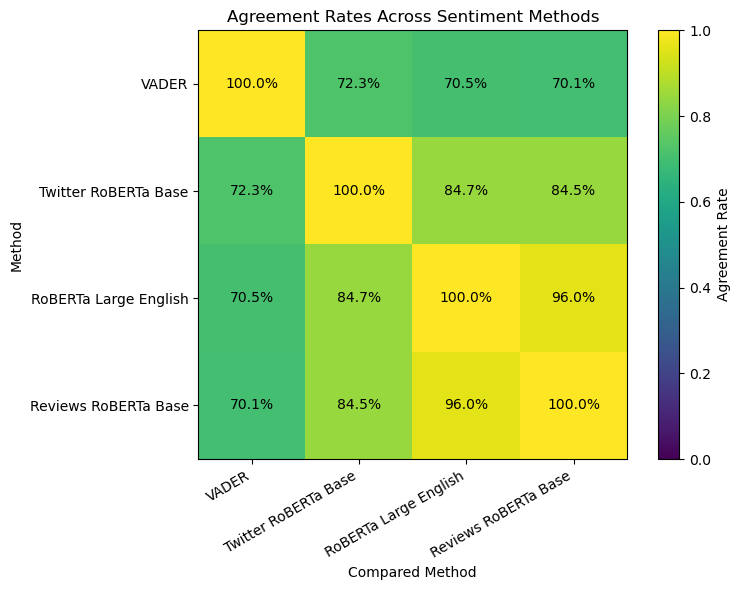

In [27]:
# Heatmap from the pairwise agreement-rate crosstab
heatmap_data = method_agreement_crosstab.astype(float)
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(heatmap_data, cmap="viridis", vmin=0, vmax=1)

ax.set_xticks(range(len(method_order)))
ax.set_yticks(range(len(method_order)))
ax.set_xticklabels(method_order, rotation=30, ha="right")
ax.set_yticklabels(method_order)
ax.set_xlabel("Compared Method")
ax.set_ylabel("Method")
ax.set_title("Agreement Rates Across Sentiment Methods")

for y in range(len(method_order)):
    for x in range(len(method_order)):
        value = heatmap_data.iloc[y, x]
        text_color = "white" if value < 0.55 else "black"
        ax.text(x, y, f"{value:.1%}", ha="center", va="center", color=text_color)

fig.colorbar(im, ax=ax, label="Agreement Rate")
plt.tight_layout()
plt.show()

## Compound Score Correlations

,VADER_CP_RVS,TWRB_CS,SRB_CS,RVRB_CS
VADER_CP_RVS,1.000,0.646,0.559,0.565
TWRB_CS,0.646,1.000,0.867,0.873
SRB_CS,0.559,0.867,1.000,0.924
RVRB_CS,0.565,0.873,0.924,1.000


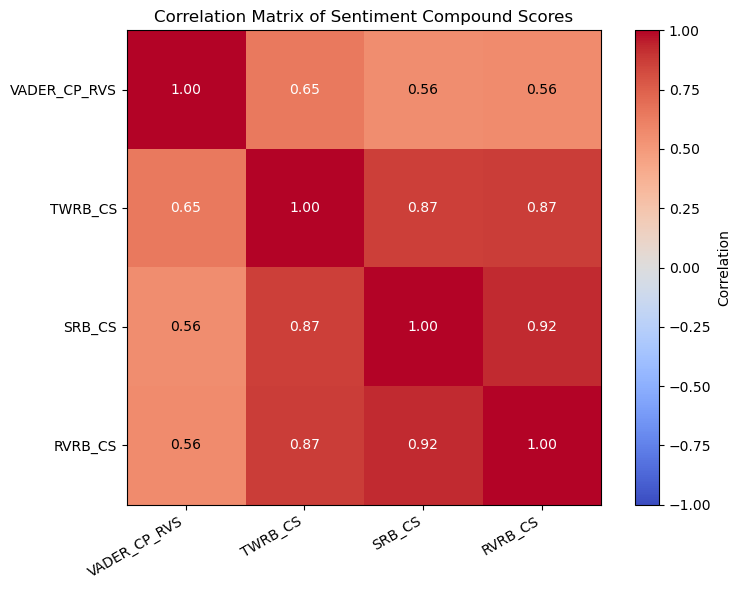

In [28]:
# Correlation matrix between compound scores for all sentiment methods
compound_score_cols = {
    "CP_RVS": "VADER_CP_RVS",
    "TWRB_CS": "TWRB_CS",
    "SRB_CS": "SRB_CS",
    "RVRB_CS": "RVRB_CS",
}

available_compound_score_cols = [
    col for col in compound_score_cols if col in toaster_clean_df.columns
]
missing_compound_score_cols = [
    col for col in compound_score_cols if col not in toaster_clean_df.columns
]

if missing_compound_score_cols:
    print(f"Missing compound-score columns: {missing_compound_score_cols}")

compound_score_df = (
    toaster_clean_df[available_compound_score_cols]
    .apply(pd.to_numeric, errors="coerce")
    .rename(columns=compound_score_cols)
)

compound_score_corr = compound_score_df.corr()
display(compound_score_corr.style.format("{:.3f}"))

# Heatmap of compound-score correlations
corr_method_order = compound_score_corr.columns.tolist()
corr_fig, corr_ax = plt.subplots(figsize=(8, 6))
corr_im = corr_ax.imshow(compound_score_corr, cmap="coolwarm", vmin=-1, vmax=1)

corr_ax.set_xticks(range(len(corr_method_order)))
corr_ax.set_yticks(range(len(corr_method_order)))
corr_ax.set_xticklabels(corr_method_order, rotation=30, ha="right")
corr_ax.set_yticklabels(corr_method_order)
corr_ax.set_title("Correlation Matrix of Sentiment Compound Scores")

for y in range(len(corr_method_order)):
    for x in range(len(corr_method_order)):
        value = compound_score_corr.iloc[y, x]
        label = "" if pd.isna(value) else f"{value:.2f}"
        text_color = "white" if pd.notna(value) and abs(value) > 0.6 else "black"
        corr_ax.text(x, y, label, ha="center", va="center", color=text_color)

corr_fig.colorbar(corr_im, ax=corr_ax, label="Correlation")
plt.tight_layout()
plt.show()

### Save Comparison Output

In [29]:
# Save Agreement Rates to CSV
agreement_summary = method_agreement_long.pivot(
    index="Method",
    columns="Compared Method",
    values="Agreement Rate"
).reset_index()
agreement_summary.to_csv(os.path.join(output_dir, "sentiment_method_agreement.csv"), index=False)

# Save Agreement Rates Crosstab to CSV
method_agreement_crosstab.to_csv(os.path.join(output_dir, "sentiment_method_agreement_crosstab.csv"), index=False)

# Save the heatmap figure
heatmap_path = os.path.join(output_dir, "sentiment_method_agreement_heatmap.png")
fig.savefig(heatmap_path, dpi=300)

# Save compound-score correlation outputs
compound_score_corr.to_csv(
    os.path.join(output_dir, "sentiment_compound_score_correlation.csv")
)
corr_heatmap_path = os.path.join(output_dir, "sentiment_compound_score_correlation_heatmap.png")
corr_fig.savefig(corr_heatmap_path, dpi=300)